# 🕐 Pronóstico Multivariado de Series de Tiempo con Amazon Chronos-2

**Autor:** Basado en el artículo de Krokoko (Medium, dic. 2025) y la documentación oficial de Amazon Science  
**Modelo:** `amazon/chronos-2` (Hugging Face)  
**Objetivo:** Aprender a usar Chronos-2 para pronóstico multivariado de series de tiempo, primero **sin covariables exógenas** y luego **con covariables pasadas y futuras**, calculando métricas completas en cada caso.

---

### 📚 Contenido del Cuadernillo

| Sección | Descripción |
|---------|-------------|
| 1. Instalación y configuración | Dependencias, imports |
| 2. Fundamentos teóricos | Qué es Chronos-2, TSFM, ICL |
| 3. Generación de datos | Dataset sintético multivariado realista |
| 4. Análisis exploratorio (EDA) | Visualización y correlaciones |
| 5. Carga del modelo | Pipeline de Chronos-2 |
| 6. **Multivariado SIN covariables** | Predicción conjunta de 4 series |
| 7. **Multivariado CON covariables pasadas** | Uso de señales históricas |
| 8. **Multivariado CON covariables futuras** | Uso de información futura conocida |
| 9. Comparación de métricas | MAE, RMSE, MAPE, CRPS, Pinball Loss, Cobertura |
| 10. Conclusiones | Cuándo usar cada enfoque |

> 💡 **Tip:** Ejecuta las celdas en orden. El modelo se descargará automáticamente desde Hugging Face la primera vez (~500 MB).


## 📦 1. Instalación de Dependencias

Chronos-2 se instala a través del paquete `chronos-forecasting`. Necesitamos al menos la versión **2.2** para acceder a las capacidades multivariadas y de covariables.


In [1]:
# ── Instalación (ejecutar solo si no están instalados) ──────────────────────
# !pip install "chronos-forecasting>=2.2" --quiet
# !pip install pandas matplotlib seaborn scikit-learn --quiet

# Verificar versión de chronos
try:
    import chronos
    version = getattr(chronos, "__version__", "(versión no expuesta)")
    print(f"✅ chronos-forecasting instalado: v{version}")
except ImportError:
    print("❌ chronos-forecasting no encontrado. Ejecuta:")
    print('   pip install "chronos-forecasting>=2.2"')


✅ chronos-forecasting instalado: v2.2.2


In [2]:
# ── Importaciones principales ────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Chronos-2
from chronos import BaseChronosPipeline

# ── Configuración visual ─────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
COLORES = ['#1976D2', '#E53935', '#43A047', '#8E24AA']   # Azul, Rojo, Verde, Morado
TARGET_LABELS = ['Ropa', 'Electrónica', 'Hogar', 'Deportes']
TARGETS = ['ventas_ropa', 'ventas_electronica', 'ventas_hogar', 'ventas_deportes']

print("✅ Librerías importadas correctamente")
print(f"   numpy  {np.__version__}")
print(f"   pandas {pd.__version__}")


✅ Librerías importadas correctamente
   numpy  2.4.4
   pandas 2.3.3


## 🧠 2. Fundamentos Teóricos

### ¿Qué es un TSFM (Time Series Foundation Model)?

Un **TSFM** es un modelo preentrenado con millones de series de tiempo diversas, capaz de hacer pronósticos **sin necesidad de reentrenamiento** en datos nuevos (aprendizaje **zero-shot**).

```
Enfoque Tradicional (ARIMA, ETS):   1 serie → 1 modelo → 1 pronóstico
Enfoque ML global (DeepAR):         N series → 1 modelo entrenado → N pronósticos  
Enfoque TSFM (Chronos-2):           Preentrenado → Zero-shot → N pronósticos  ✅
```

### ¿Qué hace especial a Chronos-2?

| Capacidad | Chronos (v1) | Chronos-Bolt | **Chronos-2** |
|-----------|:---:|:---:|:---:|
| Pronóstico Univariado | ✅ | ✅ | ✅ |
| Pronóstico **Multivariado** | ❌ | ❌ | **✅** |
| Covariables pasadas | ❌ | ❌ | **✅** |
| Covariables futuras conocidas | ❌ | ⚠️ parcial | **✅** |
| Aprendizaje cruzado (cross-learning) | ❌ | ❌ | **✅** |
| Longitud máxima de contexto | 512 | 2048 | **8192** |

### Tipos de Covariables en Chronos-2

```
┌─────────────────────────────────────────────────────────┐
│  COVARIABLES PASADAS (past-only)                         │
│  Solo disponibles en el período histórico                │
│  Ej: índice de confianza del consumidor (pasado)         │
│  → Se incluyen en context_df, NO en future_df            │
├─────────────────────────────────────────────────────────┤
│  COVARIABLES FUTURAS CONOCIDAS (known-future)            │
│  Disponibles tanto en el pasado como en el futuro        │
│  Ej: temperatura pronosticada, eventos planificados      │
│  → Se incluyen en context_df Y en future_df              │
└─────────────────────────────────────────────────────────┘
```

### Estructura de datos requerida por Chronos-2

```python
# context_df: datos históricos con targets y covariables
item_id  | timestamp  | target1 | target2 | cov_pasada | cov_futura
---------|------------|---------|---------|------------|----------
tienda_A | 2023-01-01 | 50000   | 30000   | 102.3      | -5.2
tienda_A | 2023-02-01 | 48000   | 28500   | 101.8      | -3.1
...

# future_df: covariables futuras conocidas para el horizonte de predicción
item_id  | timestamp  | cov_futura
---------|------------|----------
tienda_A | 2024-01-01 | -4.5
tienda_A | 2024-02-01 | -2.8
...
```

> 📌 **Regla clave:** Las columnas que NO son `item_id`, `timestamp` ni están en `target=[]` se tratan automáticamente como covariables.


## 📊 3. Generación de Datos Sintéticos

Simulamos las ventas mensuales de **4 categorías de productos** en una tienda retail durante 6 años (2019–2024), con patrones realistas:

- **Ropa**: pico en invierno (Dic/Ene), sensible al frío
- **Electrónica**: pico navideño fuerte, crecimiento rápido  
- **Hogar**: estacionalidad suave, dos picos anuales
- **Deportes**: pico en verano, sensible al calor

Con **3 covariables** que afectan las ventas:
1. `temperatura` — real, **futura conocida** (se puede pronosticar meteorológicamente)
2. `promocion` — binaria, **futura conocida** (campañas planificadas)
3. `indice_confianza` — real, **solo pasada** (no se conoce el futuro)


In [3]:
# ── Generación de datos sintéticos realistas ────────────────────────────────
np.random.seed(42)

N_TOTAL      = 72   # 6 años de datos mensuales
N_TRAIN      = 60   # 5 años de entrenamiento
N_TEST       = 12   # 1 año de prueba (horizonte de predicción)

dates = pd.date_range(start='2019-01-01', periods=N_TOTAL, freq='MS')
t     = np.arange(N_TOTAL)

# ── COVARIABLES (se crean primero porque afectan las ventas) ─────────────────

# 1. Temperatura (°C): ciclo estacional anual + ruido
temperatura = 15 + 12 * np.sin(2*np.pi*t/12 - np.pi/2) + np.random.normal(0, 1.5, N_TOTAL)

# 2. Promoción: Nov/Dic (temporada alta) y Jun (rebajas verano)
promocion = np.array([1 if d.month in [6, 11, 12] else 0 for d in dates], dtype=int)

# 3. Índice de confianza del consumidor: ciclo económico lento + ruido
indice_confianza = 100 + 8*np.sin(2*np.pi*t/36) + np.random.normal(0, 4, N_TOTAL)

# ── SERIES OBJETIVO (con efectos de covariables incorporados) ────────────────

# Ropa: pico invierno, crece moderado, sensible a temperatura (frío ↑) y promociones
ventas_ropa = (
    50_000 + 600*t                                         # tendencia
    + 22_000 * np.sin(2*np.pi*t/12 + np.pi/4)             # estacionalidad (pico Dic/Ene)
    - 1_500 * (temperatura - 15) / 12                      # efecto temperatura (inverso)
    + 18_000 * promocion                                   # efecto promoción
    + 250 * (indice_confianza - 100)                       # efecto confianza
    + np.random.normal(0, 3_000, N_TOTAL)                  # ruido
)

# Electrónica: pico navideño muy pronunciado, crece rápido
ventas_electronica = (
    28_000 + 1_000*t
    + 30_000 * np.sin(2*np.pi*t/12 + np.pi/3)
    + 25_000 * promocion
    + 380 * (indice_confianza - 100)
    + np.random.normal(0, 4_500, N_TOTAL)
)

# Hogar: estacionalidad doble (primavera y fin de año)
ventas_hogar = (
    42_000 + 400*t
    + 12_000 * np.sin(2*np.pi*t/12)
    + 5_000  * np.sin(4*np.pi*t/12)   # segundo armónico
    + 12_000 * promocion
    + 200 * (indice_confianza - 100)
    + np.random.normal(0, 2_500, N_TOTAL)
)

# Deportes: pico verano, sensible al calor
ventas_deportes = (
    22_000 + 300*t
    + 16_000 * np.sin(2*np.pi*t/12 - np.pi/2)             # pico Jul/Ago
    + 2_000  * (temperatura - 15) / 12                     # efecto temperatura (positivo)
    + 10_000 * promocion
    + 150 * (indice_confianza - 100)
    + np.random.normal(0, 2_000, N_TOTAL)
)

# Asegurar valores positivos y redondear a enteros
ventas_ropa        = np.maximum(ventas_ropa,        5_000).round().astype(int)
ventas_electronica = np.maximum(ventas_electronica, 5_000).round().astype(int)
ventas_hogar       = np.maximum(ventas_hogar,       5_000).round().astype(int)
ventas_deportes    = np.maximum(ventas_deportes,    3_000).round().astype(int)

# ── DATAFRAME COMPLETO ───────────────────────────────────────────────────────
df = pd.DataFrame({
    'item_id'           : 'tienda_central',
    'timestamp'         : dates,
    'ventas_ropa'       : ventas_ropa,
    'ventas_electronica': ventas_electronica,
    'ventas_hogar'      : ventas_hogar,
    'ventas_deportes'   : ventas_deportes,
    'temperatura'       : temperatura.round(1),
    'promocion'         : promocion,
    'indice_confianza'  : indice_confianza.round(1),
})

# ── DIVISIÓN TRAIN / TEST ────────────────────────────────────────────────────
df_train  = df.iloc[:N_TRAIN].copy().reset_index(drop=True)
df_test   = df.iloc[N_TRAIN:].copy().reset_index(drop=True)

# Covariables futuras disponibles para el período de predicción
df_futuro = df_test[['item_id', 'timestamp', 'temperatura', 'promocion']].copy()

# ── Resumen ──────────────────────────────────────────────────────────────────
print("=" * 60)
print("📊 DATASET GENERADO")
print("=" * 60)
print(f"  Período total : {dates[0].strftime('%Y-%m')} → {dates[-1].strftime('%Y-%m')} ({N_TOTAL} meses)")
print(f"  Entrenamiento : {dates[0].strftime('%Y-%m')} → {dates[N_TRAIN-1].strftime('%Y-%m')} ({N_TRAIN} meses)")
print(f"  Prueba        : {dates[N_TRAIN].strftime('%Y-%m')} → {dates[-1].strftime('%Y-%m')} ({N_TEST} meses)")
print()
print("📋 Estadísticas descriptivas (entrenamiento):")
print(df_train[TARGETS].describe().round(0).to_string())
print()
print("🔍 Primeras filas del dataset:")
print(df_train.head(3).to_string(index=False))


📊 DATASET GENERADO
  Período total : 2019-01 → 2024-12 (72 meses)
  Entrenamiento : 2019-01 → 2023-12 (60 meses)
  Prueba        : 2024-01 → 2024-12 (12 meses)

📋 Estadísticas descriptivas (entrenamiento):
       ventas_ropa  ventas_electronica  ventas_hogar  ventas_deportes
count         60.0                60.0          60.0             60.0
mean       72811.0             63813.0       57173.0          33721.0
std        20344.0             28626.0       10229.0          14291.0
min        32438.0              5000.0       36254.0           5141.0
25%        58122.0             45060.0       50224.0          22922.0
50%        77018.0             63266.0       56640.0          34784.0
75%        90640.0             82204.0       63428.0          43826.0
max       111908.0            126855.0       79905.0          67719.0

🔍 Primeras filas del dataset:
       item_id  timestamp  ventas_ropa  ventas_electronica  ventas_hogar  ventas_deportes  temperatura  promocion  indice_confianza
t

## 🔍 4. Análisis Exploratorio de Datos (EDA)

Antes de modelar, es fundamental entender la estructura de las series: tendencias, estacionalidad, correlaciones entre series y relaciones con covariables.


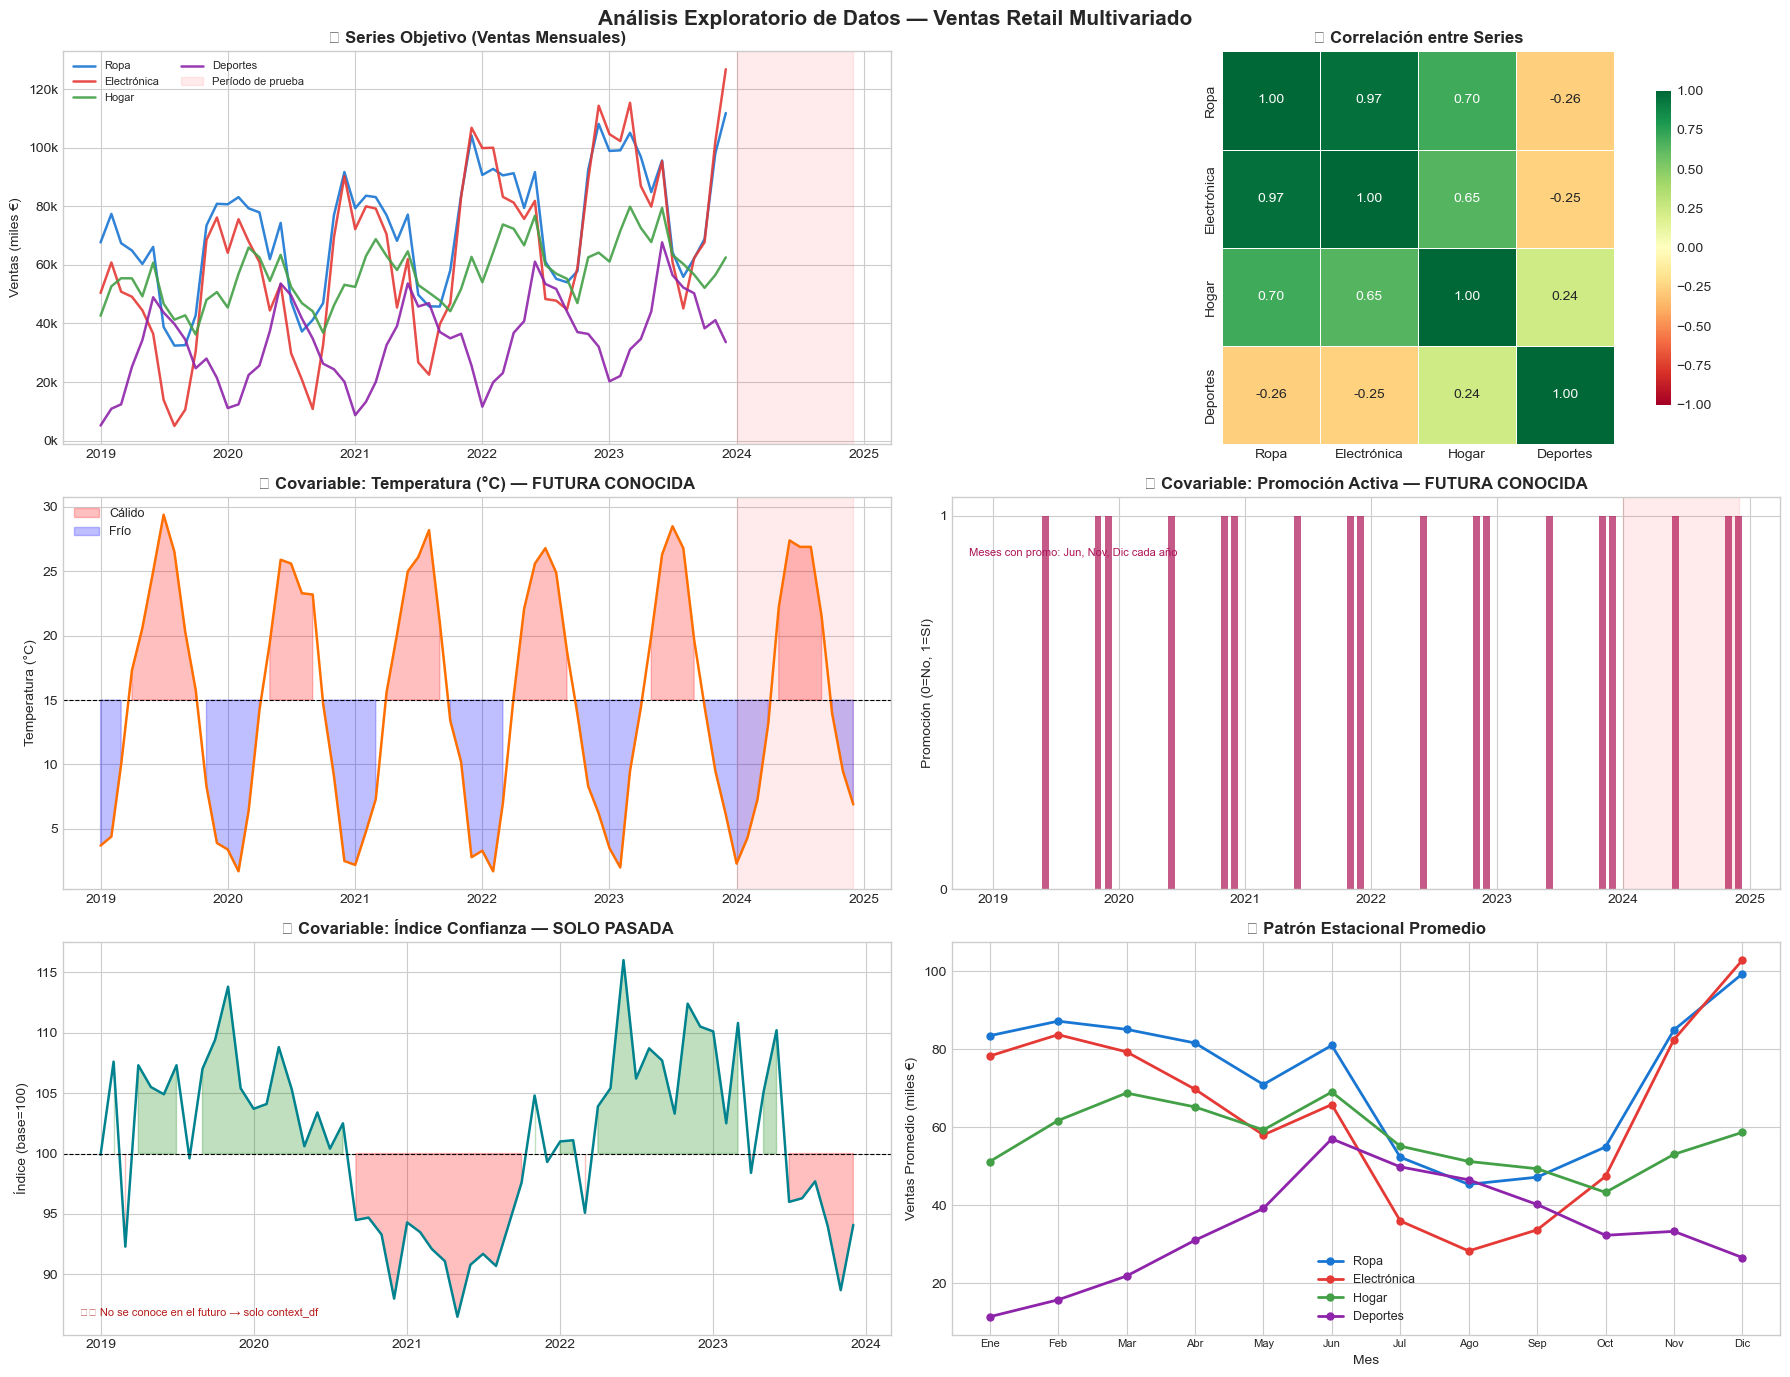

✅ EDA completado


In [4]:
# ── Análisis Exploratorio Completo ──────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Análisis Exploratorio de Datos — Ventas Retail Multivariado', 
             fontsize=15, fontweight='bold', y=0.98)

# ── Plot 1: Series históricas + zona de test ─────────────────────────────────
ax1 = fig.add_subplot(3, 2, 1)
for target, color, label in zip(TARGETS, COLORES, TARGET_LABELS):
    ax1.plot(df_train['timestamp'], df_train[target]/1000, 
             label=label, color=color, linewidth=1.8, alpha=0.9)
ax1.axvspan(df_test['timestamp'].iloc[0], df_test['timestamp'].iloc[-1],
            alpha=0.08, color='red', label='Período de prueba')
ax1.set_title('① Series Objetivo (Ventas Mensuales)', fontweight='bold')
ax1.set_ylabel('Ventas (miles €)')
ax1.legend(fontsize=8, ncol=2)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}k'))

# ── Plot 2: Correlación entre series ─────────────────────────────────────────
ax2 = fig.add_subplot(3, 2, 2)
corr = df_train[TARGETS].corr()
mask = np.zeros_like(corr, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax2,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            xticklabels=TARGET_LABELS, yticklabels=TARGET_LABELS,
            cbar_kws={'shrink': 0.8})
ax2.set_title('② Correlación entre Series', fontweight='bold')

# ── Plot 3: Temperatura ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(3, 2, 3)
ax3.plot(df['timestamp'], df['temperatura'], color='#FF6F00', linewidth=1.8)
ax3.fill_between(df['timestamp'], df['temperatura'], 15, 
                 where=(df['temperatura'] >= 15), alpha=0.25, color='red', label='Cálido')
ax3.fill_between(df['timestamp'], df['temperatura'], 15, 
                 where=(df['temperatura'] < 15), alpha=0.25, color='blue', label='Frío')
ax3.axhline(y=15, color='black', linestyle='--', linewidth=0.8)
ax3.axvspan(df_test['timestamp'].iloc[0], df_test['timestamp'].iloc[-1],
            alpha=0.08, color='red')
ax3.set_title('③ Covariable: Temperatura (°C) — FUTURA CONOCIDA', fontweight='bold')
ax3.set_ylabel('Temperatura (°C)')
ax3.legend(fontsize=9)

# ── Plot 4: Promoción ────────────────────────────────────────────────────────
ax4 = fig.add_subplot(3, 2, 4)
ax4.bar(df['timestamp'], df['promocion'], color='#AD1457', alpha=0.7, width=20)
ax4.axvspan(df_test['timestamp'].iloc[0], df_test['timestamp'].iloc[-1],
            alpha=0.08, color='red')
ax4.set_title('④ Covariable: Promoción Activa — FUTURA CONOCIDA', fontweight='bold')
ax4.set_ylabel('Promoción (0=No, 1=Sí)')
ax4.set_yticks([0, 1])
meses_promo = df[df['promocion']==1]['timestamp'].dt.strftime('%b %Y')
ax4.text(0.02, 0.85, f"Meses con promo: Jun, Nov, Dic cada año", 
         transform=ax4.transAxes, fontsize=8, color='#AD1457')

# ── Plot 5: Índice de confianza ───────────────────────────────────────────────
ax5 = fig.add_subplot(3, 2, 5)
ax5.plot(df_train['timestamp'], df_train['indice_confianza'], 
         color='#00838F', linewidth=1.8)
ax5.fill_between(df_train['timestamp'], df_train['indice_confianza'], 100,
                 where=(df_train['indice_confianza'] >= 100), alpha=0.25, color='green')
ax5.fill_between(df_train['timestamp'], df_train['indice_confianza'], 100,
                 where=(df_train['indice_confianza'] < 100), alpha=0.25, color='red')
ax5.axhline(y=100, color='black', linestyle='--', linewidth=0.8)
ax5.set_title('⑤ Covariable: Índice Confianza — SOLO PASADA', fontweight='bold')
ax5.set_ylabel('Índice (base=100)')
ax5.text(0.02, 0.05, "⚠️ No se conoce en el futuro → solo context_df", 
         transform=ax5.transAxes, fontsize=8, color='#B71C1C')

# ── Plot 6: Estacionalidad promedio ──────────────────────────────────────────
ax6 = fig.add_subplot(3, 2, 6)
df_train_copy = df_train.copy()
df_train_copy['mes'] = df_train_copy['timestamp'].dt.month
seasonal = df_train_copy.groupby('mes')[TARGETS].mean()
meses_abr = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
for target, color, label in zip(TARGETS, COLORES, TARGET_LABELS):
    ax6.plot(range(1,13), seasonal[target]/1000, 'o-', 
             color=color, label=label, linewidth=2, markersize=5)
ax6.set_title('⑥ Patrón Estacional Promedio', fontweight='bold')
ax6.set_xlabel('Mes')
ax6.set_ylabel('Ventas Promedio (miles €)')
ax6.set_xticks(range(1, 13))
ax6.set_xticklabels(meses_abr, fontsize=8)
ax6.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_completo.png', bbox_inches='tight', dpi=120)
plt.show()
print("✅ EDA completado")


## 🤖 5. Carga del Modelo Chronos-2

Chronos-2 se descarga automáticamente desde Hugging Face la primera vez. Existen varias variantes según la capacidad computacional disponible:

| Variante | Parámetros | Notas |
|----------|-----------|-------|
| `amazon/chronos-2` | 120M | **Único modelo Chronos-2** — multivariate, covariables |
| `amazon/chronos-bolt-base` | 205M | Bolt — **solo univariado**, muy rápido en CPU |
| `amazon/chronos-bolt-small` | 46M | Bolt — **solo univariado**, el más ligero | GPU potente |

> ⚡ Chronos-2 es **encoder-only**: calcula cuantiles directamente sin muestreo, por lo que no tiene parámetro `num_samples`. Esto lo hace muy rápido en CPU. Cambia `device_map="cpu"` a `"cuda"` (GPU NVIDIA) o `"mps"` (Apple Silicon) para mayor velocidad.


In [5]:
# -- Cargar el pipeline de Chronos-2 ----------------------------------------
# Solo existe UN modelo Chronos-2 en HuggingFace:
#   amazon/chronos-2  (120M parametros, encoder-only, soporte multivariate)
# Los modelos chronos-bolt-* y chronos-t5-* son univariados (sin covariables)
MODEL_ID = "amazon/chronos-2"

print(f"Cargando {MODEL_ID} ... (primera vez descarga ~500 MB)")

pipeline = BaseChronosPipeline.from_pretrained(
    MODEL_ID,
    device_map="cpu",   # cambiar a "cuda" (NVIDIA) o "mps" (Apple Silicon)
    # torch_dtype=torch.bfloat16,  # descomentar para reducir memoria en GPU
)

print(f"Modelo cargado: {type(pipeline).__name__}")
device_info = getattr(pipeline, "device", None) or getattr(pipeline, "device_map", "cpu")
print(f"Dispositivo: {device_info}")


Cargando amazon/chronos-2 ... (primera vez descarga ~500 MB)
Modelo cargado: Chronos2Pipeline
Dispositivo: cpu


## 📐 6. Funciones de Métricas

Chronos-2 genera **pronósticos probabilísticos**: no devuelve un solo número, sino una distribución de posibles futuros en forma de cuantiles.

### Métricas implementadas

| Métrica | Tipo | Descripción |
|---------|------|-------------|
| **MAE** | Punto | Error Absoluto Medio — sensible a outliers |
| **RMSE** | Punto | Raíz del Error Cuadrático Medio — penaliza errores grandes |
| **MAPE** | Punto | Error Porcentual Absoluto Medio (%) |
| **sMAPE** | Punto | MAPE simétrico — más estable cuando los valores son bajos |
| **Pinball Loss** | Probabilístico | Mide calibración de un cuantil específico |
| **Cobertura** | Intervalo | % de valores reales dentro del intervalo predicho |
| **CRPS** | Probabilístico | Continuous Ranked Probability Score — métrica global de la distribución |

> 📊 **Regla general:** Para comparar modelos determinísticos usa MAE/RMSE. Para modelos probabilísticos como Chronos-2, el **CRPS** es la métrica más completa porque evalúa toda la distribución, no solo la mediana.


In [6]:
# -- Funciones de metricas para el formato largo de Chronos-2 ----------------

def mae(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2))

def mape(y_true, y_pred, eps=1e-8):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

def smape(y_true, y_pred, eps=1e-8):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(2*np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100

def pinball_loss(y_true, y_pred_q, quantile):
    y_true, y_pred_q = np.array(y_true), np.array(y_pred_q)
    error = y_true - y_pred_q
    return np.mean(np.where(error >= 0, quantile * error, (quantile - 1) * error))

def cobertura_intervalo(y_true, q_low, q_high):
    y_true = np.array(y_true)
    return np.mean((y_true >= q_low) & (y_true <= q_high)) * 100


# -- Extractor de cuantiles para el formato LARGO de Chronos-2 ----------------
# predict_df genera:
#   item_id | timestamp | target_name | predictions | '0.1' | '0.2' | ... | '0.9'
# Una fila por (item_id, timestamp, target_name).

def extraer_cuantiles_chronos(pred_df, target):
    """
    Filtra el DF largo por target_name y devuelve un dict con:
      'timestamps', 'mean', 'q10', 'q50', 'q90'
    """
    if "target_name" not in pred_df.columns:
        print(f"ERROR: columna target_name no existe. Columnas: {pred_df.columns.tolist()}")
        return {}

    df_t = pred_df[pred_df["target_name"] == target].sort_values("timestamp").reset_index(drop=True)

    if len(df_t) == 0:
        avail = pred_df["target_name"].unique().tolist()
        print(f"AVISO: '{target}' no encontrado. Disponibles: {avail}")
        return {}

    result = {"timestamps": df_t["timestamp"].values}
    if "predictions" in df_t.columns:
        result["mean"] = df_t["predictions"].values

    # Columnas de cuantiles: '0.1', '0.5', '0.9' (string del valor decimal)
    for q_val, key in [(0.1, 'q10'), (0.5, 'q50'), (0.9, 'q90')]:
        col = str(q_val)
        if col in df_t.columns:
            result[key] = df_t[col].values
        else:
            # Formatos alternativos por compatibilidad
            for alt in [f'q{int(q_val*100)}', str(int(q_val*100))]:
                if alt in df_t.columns:
                    result[key] = df_t[alt].values
                    break

    return result


def calcular_metricas_modelo(pred_df, df_test_ref, nombre_modelo):
    """Calcula MAE, RMSE, MAPE, sMAPE, Pinball Loss y Cobertura para cada serie."""
    resultados = []

    for target, label in zip(TARGETS, TARGET_LABELS):
        y_true    = df_test_ref[target].values
        cuantiles = extraer_cuantiles_chronos(pred_df, target)

        if "q50" not in cuantiles:
            print(f"AVISO: sin q50 para {target} -- se omite")
            continue

        y_med     = cuantiles["q50"]
        mae_val   = mae(y_true, y_med)
        rmse_val  = rmse(y_true, y_med)
        mape_val  = mape(y_true, y_med)
        smape_val = smape(y_true, y_med)
        cob_80 = pl_q10 = pl_q90 = np.nan
        pl_q50 = pinball_loss(y_true, y_med, 0.5)

        if "q10" in cuantiles and "q90" in cuantiles:
            cob_80 = cobertura_intervalo(y_true, cuantiles["q10"], cuantiles["q90"])
            pl_q10 = pinball_loss(y_true, cuantiles["q10"], 0.1)
            pl_q90 = pinball_loss(y_true, cuantiles["q90"], 0.9)

        resultados.append({
            "Modelo"   : nombre_modelo,
            "Serie"    : label,
            "MAE"      : round(mae_val,   0),
            "RMSE"     : round(rmse_val,  0),
            "MAPE (%)" : round(mape_val,  2),
            "sMAPE (%)": round(smape_val, 2),
            "PL q10"   : round(pl_q10, 0) if not np.isnan(pl_q10) else np.nan,
            "PL q50"   : round(pl_q50, 0),
            "PL q90"   : round(pl_q90, 0) if not np.isnan(pl_q90) else np.nan,
            "Cob. 80%" : round(cob_80, 1) if not np.isnan(cob_80) else np.nan,
        })

    if not resultados:
        print("ERROR: ninguna serie genero metricas.")
        return pd.DataFrame()
    return pd.DataFrame(resultados)


print("Funciones definidas. Formato largo de Chronos-2:")
print("  item_id | timestamp | target_name | predictions | '0.1' | ... | '0.9'")


Funciones definidas. Formato largo de Chronos-2:
  item_id | timestamp | target_name | predictions | '0.1' | ... | '0.9'


---

## 🔵 7. Pronóstico Multivariado — SIN Covariables Exógenas

En este primer escenario, Chronos-2 pronostica **conjuntamente las 4 series** utilizando únicamente su historial. 

**¿Por qué multivariado vs. 4 modelos univariados separados?**
- Chronos-2 captura las **correlaciones entre series** dentro del mismo ítem
- El aprendizaje cruzado permite que una serie "aprenda" de los patrones de las otras
- Una sola llamada genera todos los pronósticos de manera coherente

```python
# Estructura de context_df para este caso
context_df = df_train[['item_id', 'timestamp', 
                         'ventas_ropa', 'ventas_electronica', 
                         'ventas_hogar', 'ventas_deportes']]
#                                ↑ Solo targets, sin covariables
```


In [7]:
# ── PASO 1: Preparar datos (solo targets, sin covariables) ──────────────────
context_sin_cov = df_train[['item_id', 'timestamp'] + TARGETS].copy()

print("📋 Estructura de context_df (sin covariables):")
print(f"   Filas    : {len(context_sin_cov)}")
print(f"   Columnas : {context_sin_cov.columns.tolist()}")
print()
print(context_sin_cov.tail(3).to_string(index=False))


📋 Estructura de context_df (sin covariables):
   Filas    : 60
   Columnas : ['item_id', 'timestamp', 'ventas_ropa', 'ventas_electronica', 'ventas_hogar', 'ventas_deportes']

       item_id  timestamp  ventas_ropa  ventas_electronica  ventas_hogar  ventas_deportes
tienda_central 2023-10-01        68881               67761         52177            38352
tienda_central 2023-11-01        98207              102272         56588            41140
tienda_central 2023-12-01       111908              126855         62580            33612


In [8]:
# -- PASO 2: Generar predicciones SIN covariables ----------------------------
# Chronos-2 es encoder-only: calcula cuantiles directamente, sin muestreo.
print("Generando pronostico multivariado SIN covariables...")

pred_sin_cov = pipeline.predict_df(
    context_sin_cov,
    prediction_length=N_TEST,
    timestamp_column="timestamp",
    target=TARGETS,                  # lista de columnas = modo multivariado
    quantile_levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
)

print(f"Forma del resultado : {pred_sin_cov.shape}")
print(f"Columnas           : {pred_sin_cov.columns.tolist()}")
print(pred_sin_cov.head(4).to_string(index=False))


Generando pronostico multivariado SIN covariables...
Forma del resultado : (48, 13)
Columnas           : ['item_id', 'timestamp', 'target_name', 'predictions', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9']
       item_id  timestamp target_name   predictions           0.1           0.2           0.3           0.4           0.5           0.6           0.7           0.8           0.9
tienda_central 2024-01-01 ventas_ropa 107075.484375 102015.312500 104366.156250 105606.265625 106279.093750 107075.484375 107599.960938 108534.328125 109661.781250 111387.179688
tienda_central 2024-02-01 ventas_ropa 108406.531250 103192.835938 105642.453125 106939.546875 107620.039062 108406.531250 108913.195312 109643.703125 110873.117188 112598.875000
tienda_central 2024-03-01 ventas_ropa 108736.906250 103231.406250 105903.085938 107086.046875 107933.859375 108736.906250 109240.757812 110015.875000 111277.906250 112691.015625
tienda_central 2024-04-01 ventas_ropa 105015.054688  99604.671875

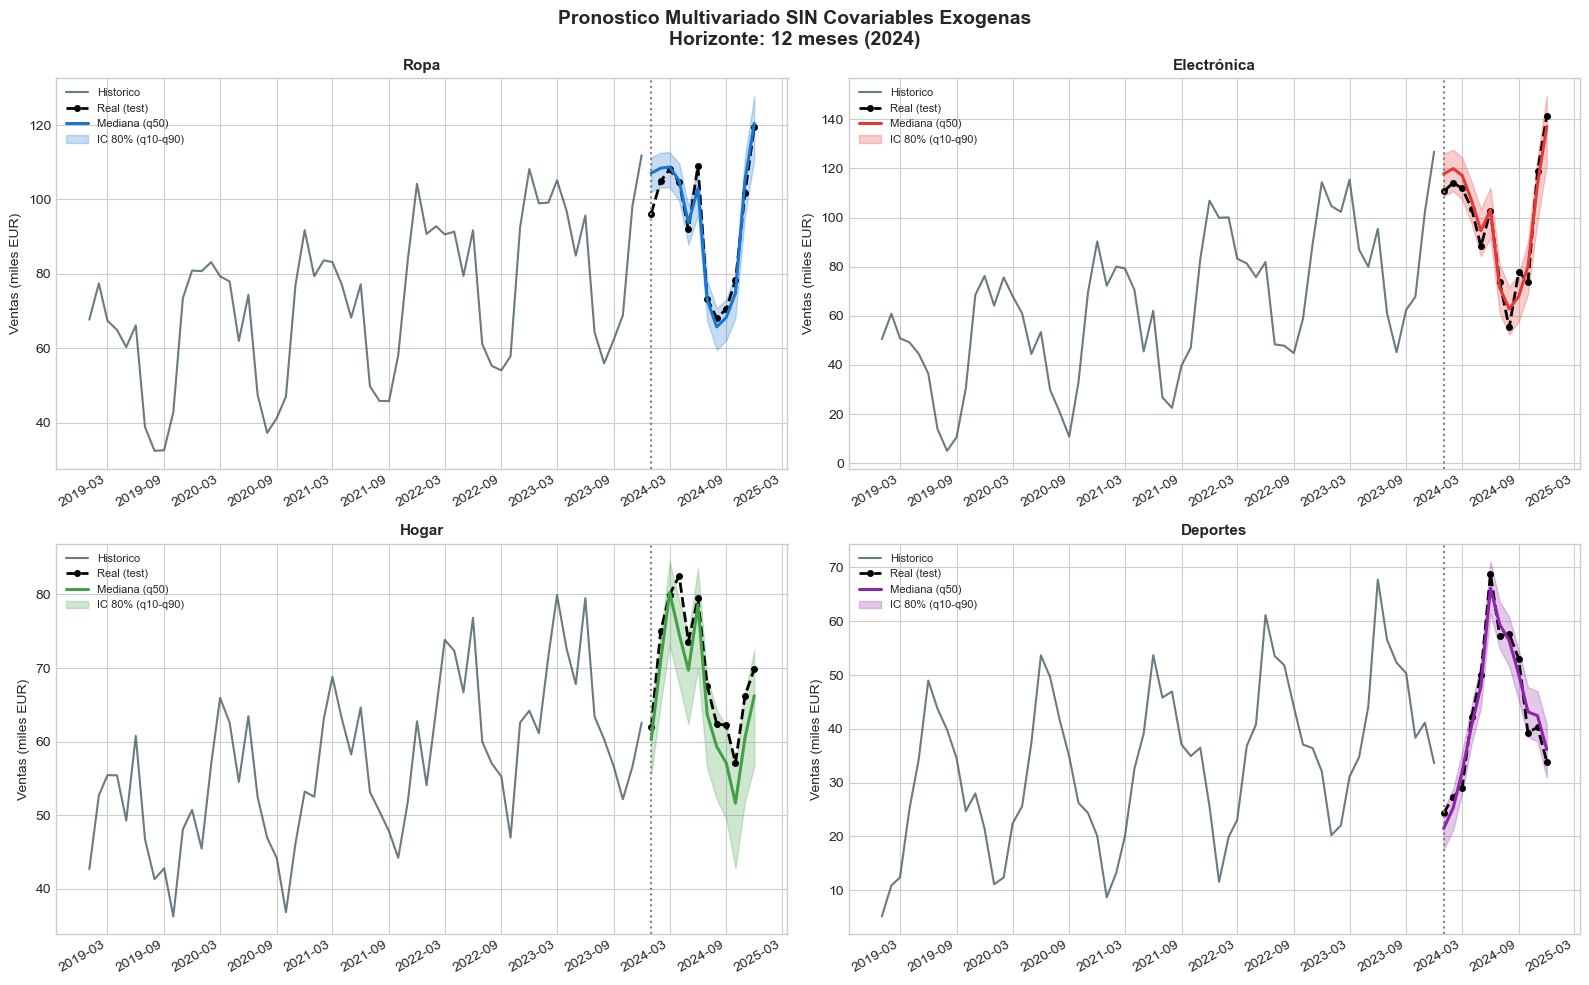

In [9]:
# -- PASO 3: Visualizacion SIN covariables -----------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Pronostico Multivariado SIN Covariables Exogenas\n'
             f'Horizonte: {N_TEST} meses (2024)',
             fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for idx, (target, color, label) in enumerate(zip(TARGETS, COLORES, TARGET_LABELS)):
    ax = axes_flat[idx]
    ax.plot(df_train['timestamp'], df_train[target]/1000,
            color='#455A64', linewidth=1.5, label='Historico', alpha=0.8)
    ax.plot(df_test['timestamp'], df_test[target]/1000,
            color='black', linewidth=2, linestyle='--',
            label='Real (test)', marker='o', markersize=4)

    # extraer_cuantiles_chronos filtra el DF largo por target_name
    q = extraer_cuantiles_chronos(pred_sin_cov, target)
    if q:
        if 'q50' in q:
            ax.plot(q['timestamps'], q['q50']/1000,
                    color=color, linewidth=2.2, label='Mediana (q50)', zorder=5)
        if 'q10' in q and 'q90' in q:
            ax.fill_between(q['timestamps'], q['q10']/1000, q['q90']/1000,
                            alpha=0.25, color=color, label='IC 80% (q10-q90)')

    ax.axvline(x=df_test['timestamp'].iloc[0], color='gray', linestyle=':', linewidth=1.5)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_ylabel('Ventas (miles EUR)')
    ax.legend(fontsize=8, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('pred_sin_covariables.png', bbox_inches='tight', dpi=120)
plt.show()


In [10]:
# -- PASO 4: Calcular metricas SIN covariables -------------------------------
metricas_sin_cov = calcular_metricas_modelo(pred_sin_cov, df_test, "Sin covariables")

if not metricas_sin_cov.empty:
    print("=" * 70)
    print("METRICAS -- Pronostico Multivariado SIN Covariables")
    print("=" * 70)
    print(metricas_sin_cov.drop(columns=["Modelo"]).to_string(index=False))
    print()
    avg = metricas_sin_cov[["MAE","RMSE","MAPE (%)","sMAPE (%)","PL q50","Cob. 80%"]].mean().round(2)
    print("Promedios:")
    print(avg.to_string())
    cob = metricas_sin_cov["Cob. 80%"].mean()
    print(f"\nCobertura 80%: {cob:.1f}%  (ideal = 80%)")


METRICAS -- Pronostico Multivariado SIN Covariables
      Serie    MAE   RMSE  MAPE (%)  sMAPE (%)  PL q10  PL q50  PL q90  Cob. 80%
       Ropa 2983.0 4138.0      3.21       3.18  1075.0  1492.0   634.0      83.3
Electrónica 5355.0 5878.0      6.09       6.01   931.0  2678.0  1159.0      91.7
      Hogar 3807.0 4325.0      5.57       5.78  1124.0  1904.0   446.0      66.7
   Deportes 2390.0 2485.0      6.17       6.17   456.0  1195.0   405.0     100.0

Promedios:
MAE          3633.75
RMSE         4206.50
MAPE (%)        5.26
sMAPE (%)       5.28
PL q50       1817.25
Cob. 80%       85.42

Cobertura 80%: 85.4%  (ideal = 80%)


---

## 🟢 8. Pronóstico Multivariado — CON Covariables Pasadas

En este escenario añadimos el **Índice de Confianza del Consumidor**, una variable que:
- ✅ Tenemos disponible históricamente
- ❌ **No conocemos en el futuro** (no se puede pronosticar con certeza)

Por eso se llama **covariable solo-pasada**: se incluye en `context_df` pero **no** en `future_df`. Chronos-2 aprende su relación con las ventas a partir del historial.

```python
# La covariable pasada va SOLO en context_df
context_df = df_train[['item_id', 'timestamp', 
                         'ventas_ropa', ...,           # targets
                         'indice_confianza']]          # ← covariable pasada

# NO hay future_df porque no conocemos el índice de confianza futuro
```


In [11]:
# ── PASO 1: Preparar datos CON covariable pasada ────────────────────────────
context_cov_pasada = df_train[
    ['item_id', 'timestamp'] + TARGETS + ['indice_confianza']
].copy()

print("📋 Estructura de context_df (con covariable pasada):")
print(f"   Filas    : {len(context_cov_pasada)}")
print(f"   Columnas : {context_cov_pasada.columns.tolist()}")
print()
print("✅ 'indice_confianza' → covariable pasada (solo context_df)")
print("❌ No hay future_df porque el índice futuro no se conoce")
print()
print(context_cov_pasada.tail(3).to_string(index=False))


📋 Estructura de context_df (con covariable pasada):
   Filas    : 60
   Columnas : ['item_id', 'timestamp', 'ventas_ropa', 'ventas_electronica', 'ventas_hogar', 'ventas_deportes', 'indice_confianza']

✅ 'indice_confianza' → covariable pasada (solo context_df)
❌ No hay future_df porque el índice futuro no se conoce

       item_id  timestamp  ventas_ropa  ventas_electronica  ventas_hogar  ventas_deportes  indice_confianza
tienda_central 2023-10-01        68881               67761         52177            38352              94.0
tienda_central 2023-11-01        98207              102272         56588            41140              88.7
tienda_central 2023-12-01       111908              126855         62580            33612              94.1


In [12]:
# -- PASO 2: Generar predicciones CON covariable pasada ----------------------
print("Generando pronostico multivariado CON covariable pasada...")

pred_cov_pasada = pipeline.predict_df(
    context_cov_pasada,
    prediction_length=N_TEST,
    timestamp_column="timestamp",
    target=TARGETS,
    quantile_levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
)

print(f"Forma : {pred_cov_pasada.shape}")


Generando pronostico multivariado CON covariable pasada...
Forma : (48, 13)


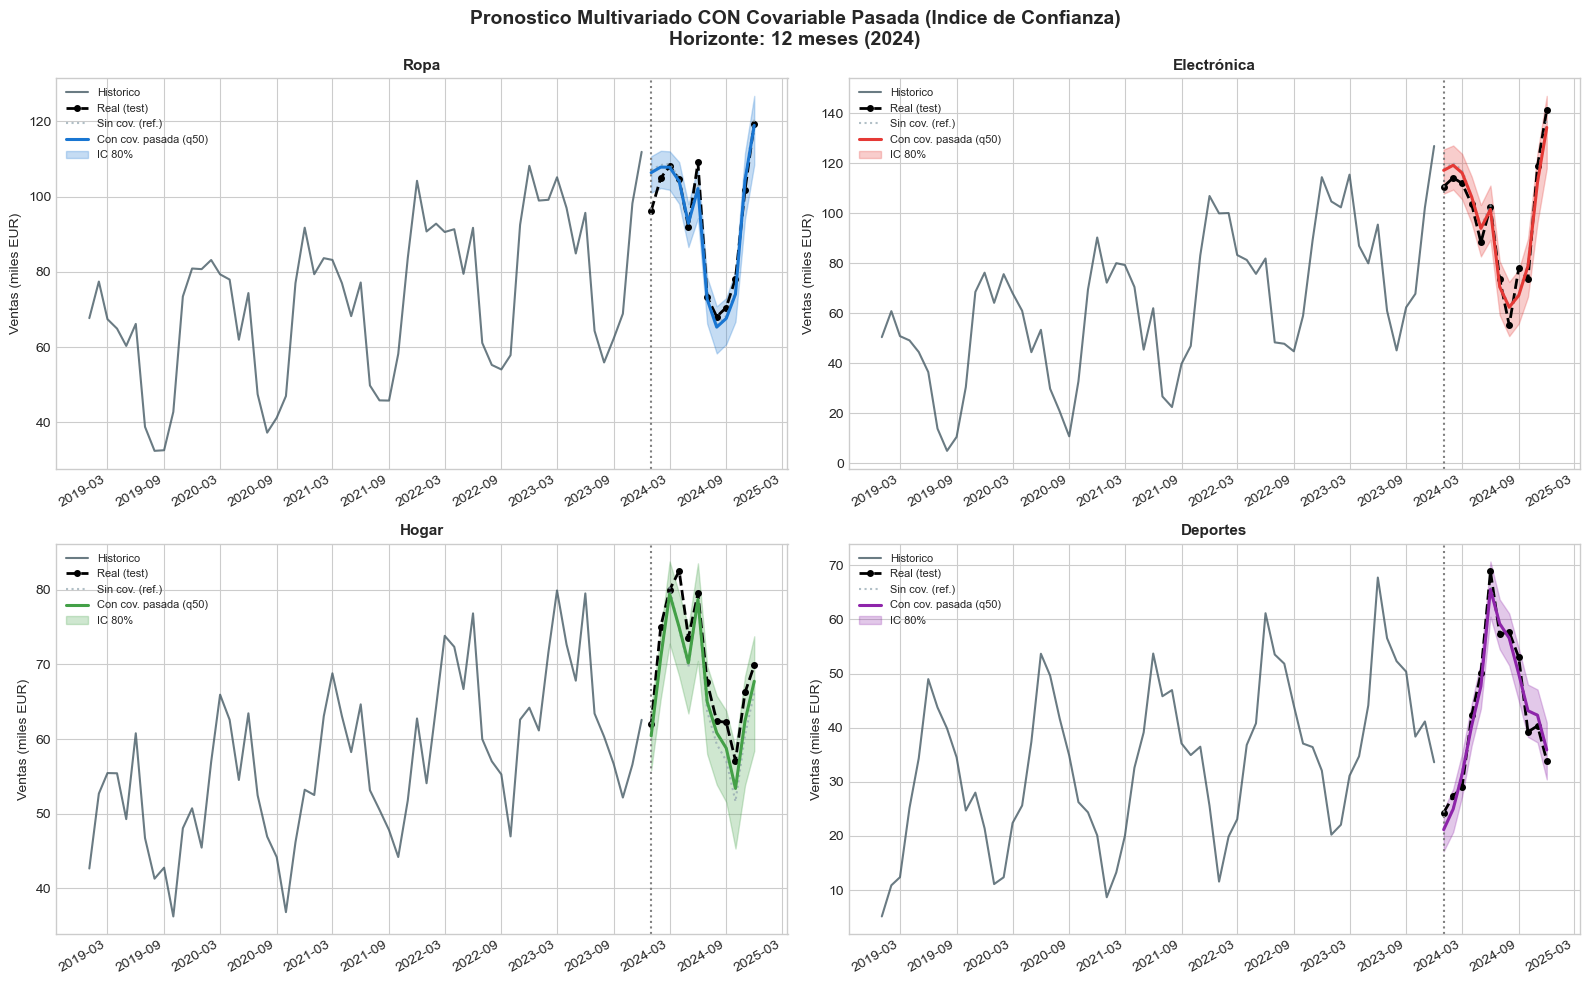

In [13]:
# -- PASO 3: Visualizacion CON covariable pasada -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Pronostico Multivariado CON Covariable Pasada (Indice de Confianza)\n'
             f'Horizonte: {N_TEST} meses (2024)',
             fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for idx, (target, color, label) in enumerate(zip(TARGETS, COLORES, TARGET_LABELS)):
    ax = axes_flat[idx]
    ax.plot(df_train['timestamp'], df_train[target]/1000,
            color='#455A64', linewidth=1.5, label='Historico', alpha=0.8)
    ax.plot(df_test['timestamp'], df_test[target]/1000,
            color='black', linewidth=2, linestyle='--',
            label='Real (test)', marker='o', markersize=4)

    ref = extraer_cuantiles_chronos(pred_sin_cov, target)
    if 'q50' in ref:
        ax.plot(ref['timestamps'], ref['q50']/1000,
                color='#90A4AE', linewidth=1.5, linestyle=':',
                label='Sin cov. (ref.)', alpha=0.7)

    q = extraer_cuantiles_chronos(pred_cov_pasada, target)
    if q:
        if 'q50' in q:
            ax.plot(q['timestamps'], q['q50']/1000,
                    color=color, linewidth=2.2, label='Con cov. pasada (q50)', zorder=5)
        if 'q10' in q and 'q90' in q:
            ax.fill_between(q['timestamps'], q['q10']/1000, q['q90']/1000,
                            alpha=0.25, color=color, label='IC 80%')

    ax.axvline(x=df_test['timestamp'].iloc[0], color='gray', linestyle=':', linewidth=1.5)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_ylabel('Ventas (miles EUR)')
    ax.legend(fontsize=8, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('pred_cov_pasada.png', bbox_inches='tight', dpi=120)
plt.show()


In [14]:
# -- PASO 4: Metricas CON covariable pasada ----------------------------------
metricas_cov_pasada = calcular_metricas_modelo(pred_cov_pasada, df_test, "Cov. pasada")

if not metricas_cov_pasada.empty:
    print("=" * 70)
    print("METRICAS -- Pronostico Multivariado CON Covariable Pasada")
    print("=" * 70)
    print(metricas_cov_pasada.drop(columns=["Modelo"]).to_string(index=False))
    print()
    mae_ref = metricas_sin_cov["MAE"].mean()
    mae_cov = metricas_cov_pasada["MAE"].mean()
    cambio  = (mae_ref - mae_cov) / mae_ref * 100
    print(f"MAE sin cov: {mae_ref:,.0f}  |  MAE con cov. pasada: {mae_cov:,.0f}")
    print(f"Variacion: {'Mejora' if cambio > 0 else 'Empeora'} {abs(cambio):.1f}%")


METRICAS -- Pronostico Multivariado CON Covariable Pasada
      Serie    MAE   RMSE  MAPE (%)  sMAPE (%)  PL q10  PL q50  PL q90  Cob. 80%
       Ropa 2942.0 4103.0      3.23       3.23  1133.0  1471.0   635.0      83.3
Electrónica 5453.0 5960.0      6.09       6.08  1120.0  2727.0  1094.0      91.7
      Hogar 2942.0 3457.0      4.23       4.35  1006.0  1471.0   497.0      83.3
   Deportes 2449.0 2559.0      6.28       6.34   504.0  1224.0   401.0     100.0

MAE sin cov: 3,634  |  MAE con cov. pasada: 3,446
Variacion: Mejora 5.2%


---

## 🟣 9. Pronóstico Multivariado — CON Todas las Covariables (Pasadas + Futuras)

Este es el escenario más completo. Añadimos las covariables **futuras conocidas** (`temperatura` y `promocion`) que Chronos-2 puede usar para **anticipar** eventos que ya sabemos van a ocurrir.

**Intuición:** Si sabemos que diciembre tendrá promociones y bajas temperaturas, el modelo puede predecir con mucha mayor precisión el pico de ventas de ropa y electrónica.

```python
# Todas las covariables en context_df (historial completo)
context_df = df_train[['item_id', 'timestamp', 
                         'ventas_ropa', ...,           # targets
                         'temperatura', 'promocion',   # ← futuras conocidas
                         'indice_confianza']]          # ← solo pasada

# future_df: valores FUTUROS de las covariables conocidas
future_df = df_futuro[['item_id', 'timestamp',
                         'temperatura', 'promocion']]  # ← solo las futuras conocidas
#                        ↑ NO se incluye indice_confianza porque no lo conocemos
```

> 🔑 **Clave:** El modelo aprende durante el entrenamiento que la `temperatura` y la `promocion` tienen un efecto específico en cada categoría. Al darle los valores futuros de estas variables, puede hacer predicciones mucho más precisas.


In [15]:
# ── PASO 1: Preparar datos CON todas las covariables ────────────────────────
context_todas_cov = df_train[
    ['item_id', 'timestamp'] + TARGETS + 
    ['temperatura', 'promocion', 'indice_confianza']  # ← todas las covariables
].copy()

# future_df: solo las covariables futuras conocidas
# (temperatura y promocion — NO el índice de confianza que no conocemos)
future_todas_cov = df_futuro[
    ['item_id', 'timestamp', 'temperatura', 'promocion']
].copy()

print("📋 Estructura de context_df (con todas las covariables):")
print(f"   Filas    : {len(context_todas_cov)}")
print(f"   Columnas : {context_todas_cov.columns.tolist()}")
print()
print("📋 Estructura de future_df (covariables futuras conocidas):")
print(f"   Filas    : {len(future_todas_cov)}")
print(f"   Columnas : {future_todas_cov.columns.tolist()}")
print()
print("🔍 future_df — valores del período de predicción:")
print(future_todas_cov.to_string(index=False))


📋 Estructura de context_df (con todas las covariables):
   Filas    : 60
   Columnas : ['item_id', 'timestamp', 'ventas_ropa', 'ventas_electronica', 'ventas_hogar', 'ventas_deportes', 'temperatura', 'promocion', 'indice_confianza']

📋 Estructura de future_df (covariables futuras conocidas):
   Filas    : 12
   Columnas : ['item_id', 'timestamp', 'temperatura', 'promocion']

🔍 future_df — valores del período de predicción:
       item_id  timestamp  temperatura  promocion
tienda_central 2024-01-01          2.3          0
tienda_central 2024-02-01          4.3          0
tienda_central 2024-03-01          7.3          0
tienda_central 2024-04-01         13.2          0
tienda_central 2024-05-01         22.2          0
tienda_central 2024-06-01         27.4          1
tienda_central 2024-07-01         26.9          0
tienda_central 2024-08-01         26.9          0
tienda_central 2024-09-01         21.5          0
tienda_central 2024-10-01         14.0          0
tienda_central 2024-11-0

In [16]:
# -- PASO 2: Generar predicciones CON todas las covariables ------------------
print("Generando pronostico multivariado CON todas las covariables...")

pred_todas_cov = pipeline.predict_df(
    context_todas_cov,
    future_df=future_todas_cov,
    prediction_length=N_TEST,
    timestamp_column="timestamp",
    target=TARGETS,
    quantile_levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
)

print(f"Forma : {pred_todas_cov.shape}")
print()
# Columnas de salida: {target}_q{percentil}  ej: ventas_ropa_q10
print("Columnas de la prediccion:")
for col in pred_todas_cov.columns:
    print(f"   {col}")


Generando pronostico multivariado CON todas las covariables...
Forma : (48, 13)

Columnas de la prediccion:
   item_id
   timestamp
   target_name
   predictions
   0.1
   0.2
   0.3
   0.4
   0.5
   0.6
   0.7
   0.8
   0.9


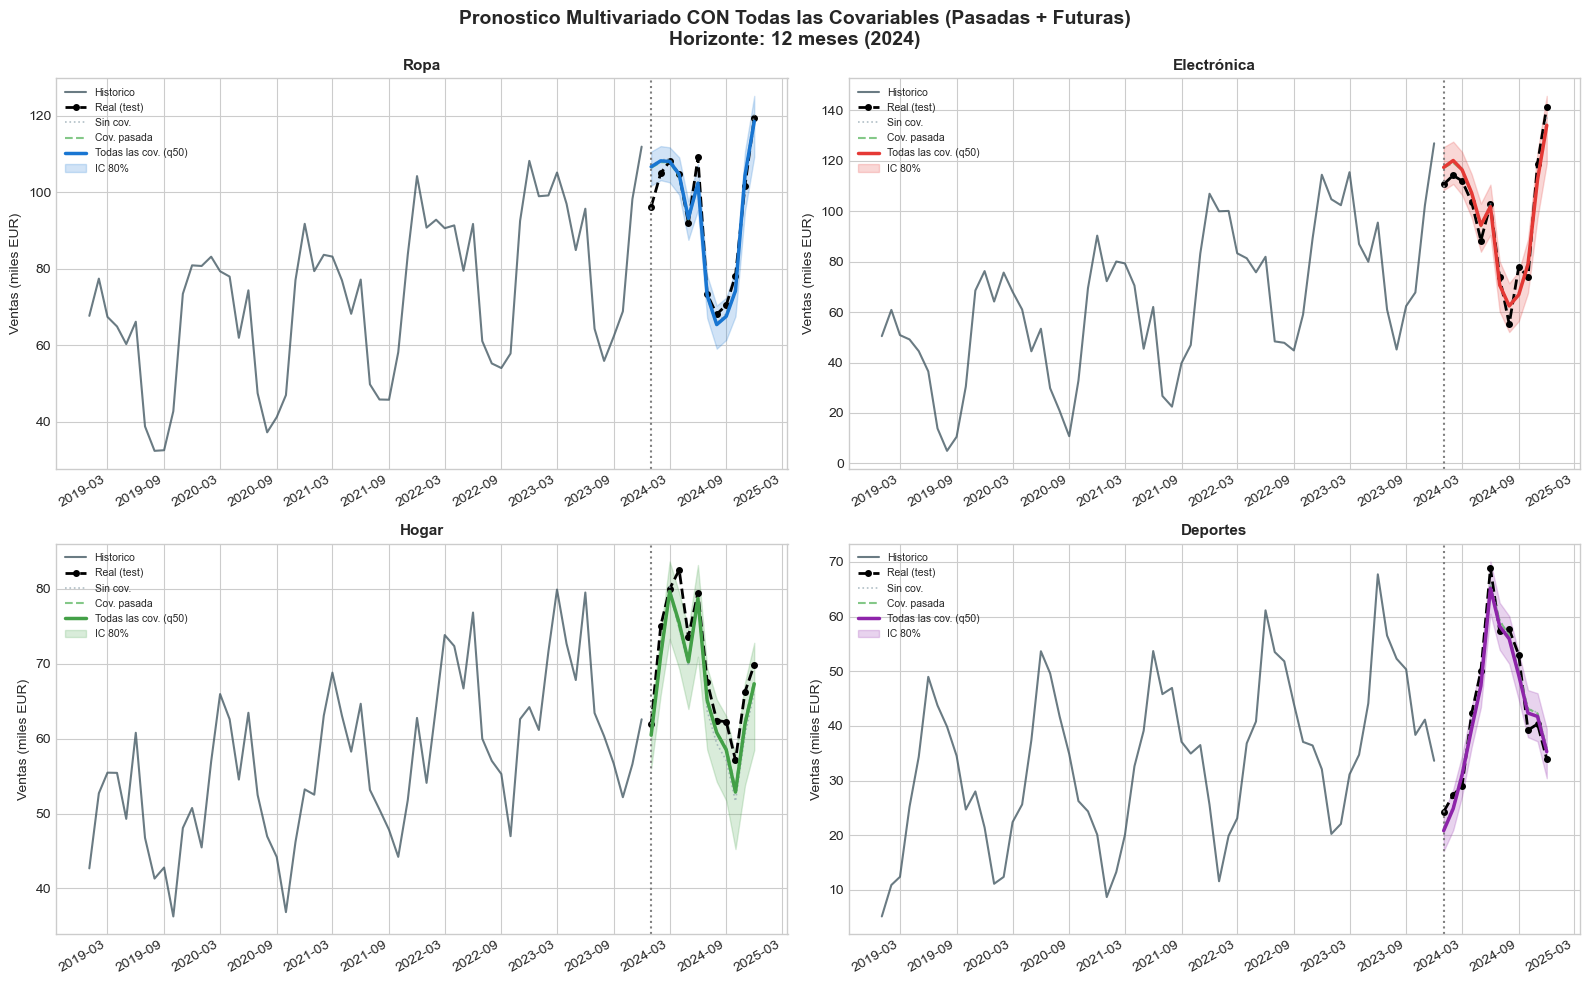

In [17]:
# -- PASO 3: Visualizacion CON todas las covariables -------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Pronostico Multivariado CON Todas las Covariables (Pasadas + Futuras)\n'
             f'Horizonte: {N_TEST} meses (2024)',
             fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for idx, (target, color, label) in enumerate(zip(TARGETS, COLORES, TARGET_LABELS)):
    ax = axes_flat[idx]
    ax.plot(df_train['timestamp'], df_train[target]/1000,
            color='#455A64', linewidth=1.5, label='Historico', alpha=0.8)
    ax.plot(df_test['timestamp'], df_test[target]/1000,
            color='black', linewidth=2, linestyle='--',
            label='Real (test)', marker='o', markersize=4)

    ref = extraer_cuantiles_chronos(pred_sin_cov, target)
    if 'q50' in ref:
        ax.plot(ref['timestamps'], ref['q50']/1000,
                color='#90A4AE', linewidth=1.2, linestyle=':', label='Sin cov.', alpha=0.7)

    pas = extraer_cuantiles_chronos(pred_cov_pasada, target)
    if 'q50' in pas:
        ax.plot(pas['timestamps'], pas['q50']/1000,
                color='#66BB6A', linewidth=1.5, linestyle='--',
                label='Cov. pasada', alpha=0.8)

    q = extraer_cuantiles_chronos(pred_todas_cov, target)
    if q:
        if 'q50' in q:
            ax.plot(q['timestamps'], q['q50']/1000,
                    color=color, linewidth=2.5, label='Todas las cov. (q50)', zorder=6)
        if 'q10' in q and 'q90' in q:
            ax.fill_between(q['timestamps'], q['q10']/1000, q['q90']/1000,
                            alpha=0.2, color=color, label='IC 80%')

    ax.axvline(x=df_test['timestamp'].iloc[0], color='gray', linestyle=':', linewidth=1.5)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_ylabel('Ventas (miles EUR)')
    ax.legend(fontsize=7.5, loc='upper left', ncol=1)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('pred_todas_cov.png', bbox_inches='tight', dpi=120)
plt.show()


In [18]:
# -- PASO 4: Metricas CON todas las covariables ------------------------------
metricas_todas_cov = calcular_metricas_modelo(pred_todas_cov, df_test, "Todas las cov.")

if not metricas_todas_cov.empty:
    print("=" * 70)
    print("METRICAS -- Pronostico Multivariado CON Todas las Covariables")
    print("=" * 70)
    print(metricas_todas_cov.drop(columns=["Modelo"]).to_string(index=False))


METRICAS -- Pronostico Multivariado CON Todas las Covariables
      Serie    MAE   RMSE  MAPE (%)  sMAPE (%)  PL q10  PL q50  PL q90  Cob. 80%
       Ropa 2930.0 4143.0      3.21       3.19  1101.0  1465.0   632.0      83.3
Electrónica 5671.0 6185.0      6.30       6.28  1020.0  2836.0  1139.0      91.7
      Hogar 2998.0 3487.0      4.34       4.47   973.0  1499.0   460.0      83.3
   Deportes 2441.0 2609.0      6.20       6.34   521.0  1220.0   324.0      91.7


---

## 📊 10. Comparación Final de Métricas

Consolidamos los resultados de los tres enfoques para ver claramente el impacto de añadir covariables.


In [19]:
# ── Tabla comparativa completa ───────────────────────────────────────────────
df_metricas_todas = pd.concat(
    [metricas_sin_cov, metricas_cov_pasada, metricas_todas_cov],
    ignore_index=True
)

print("=" * 90)
print("📊 COMPARACIÓN COMPLETA DE MÉTRICAS POR MODELO Y SERIE")
print("=" * 90)
print()

# Mostrar tabla pivoteada por métrica
for target, label in zip(TARGETS, TARGET_LABELS):
    subset = df_metricas_todas[df_metricas_todas['Serie'] == label].copy()
    subset = subset.set_index('Modelo')
    print(f"▶ {label.upper()}")
    print(subset[['MAE', 'RMSE', 'MAPE (%)', 'sMAPE (%)', 'PL q50', 'Cob. 80%']].to_string())
    print()

print("=" * 90)
print("📊 PROMEDIOS POR MODELO (todas las series)")
print("=" * 90)
resumen = df_metricas_todas.groupby('Modelo')[
    ['MAE', 'RMSE', 'MAPE (%)', 'sMAPE (%)', 'PL q50', 'Cob. 80%']
].mean().round(2)
print(resumen.to_string())


📊 COMPARACIÓN COMPLETA DE MÉTRICAS POR MODELO Y SERIE

▶ ROPA
                    MAE    RMSE  MAPE (%)  sMAPE (%)  PL q50  Cob. 80%
Modelo                                                                
Sin covariables  2983.0  4138.0      3.21       3.18  1492.0      83.3
Cov. pasada      2942.0  4103.0      3.23       3.23  1471.0      83.3
Todas las cov.   2930.0  4143.0      3.21       3.19  1465.0      83.3

▶ ELECTRÓNICA
                    MAE    RMSE  MAPE (%)  sMAPE (%)  PL q50  Cob. 80%
Modelo                                                                
Sin covariables  5355.0  5878.0      6.09       6.01  2678.0      91.7
Cov. pasada      5453.0  5960.0      6.09       6.08  2727.0      91.7
Todas las cov.   5671.0  6185.0      6.30       6.28  2836.0      91.7

▶ HOGAR
                    MAE    RMSE  MAPE (%)  sMAPE (%)  PL q50  Cob. 80%
Modelo                                                                
Sin covariables  3807.0  4325.0      5.57       5.78  1904.0  

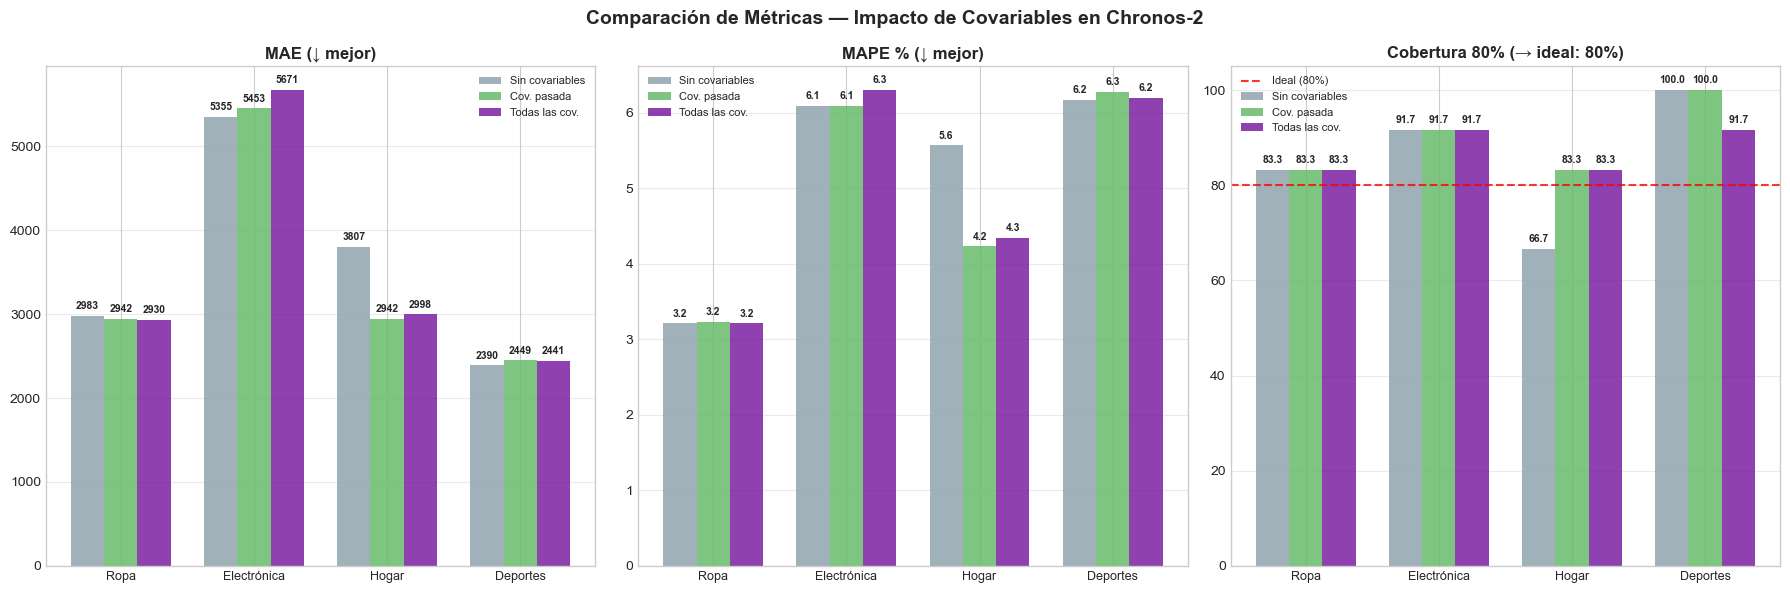


📈 MEJORA DEL MAE (respecto al modelo sin covariables)
  ✅ Cov. pasada          : +5.2%
  ✅ Todas las cov.       : +3.4%


In [20]:
# ── Gráficos de comparación visual de métricas ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparación de Métricas — Impacto de Covariables en Chronos-2',
             fontsize=14, fontweight='bold')

modelos = ['Sin covariables', 'Cov. pasada', 'Todas las cov.']
bar_colors = ['#90A4AE', '#66BB6A', '#7B1FA2']
x = np.arange(len(TARGET_LABELS))
width = 0.25

for ax, metrica, titulo in zip(
    axes,
    ['MAE', 'MAPE (%)', 'Cob. 80%'],
    ['MAE (↓ mejor)', 'MAPE % (↓ mejor)', 'Cobertura 80% (→ ideal: 80%)']
):
    for i, (modelo, color) in enumerate(zip(modelos, bar_colors)):
        vals = df_metricas_todas[df_metricas_todas['Modelo'] == modelo][metrica].values
        bars = ax.bar(x + i*width, vals, width, label=modelo, color=color, alpha=0.85)
        # Etiquetas en las barras
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(vals),
                       f'{v:.0f}' if metrica == 'MAE' else f'{v:.1f}',
                       ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    
    if metrica == 'Cob. 80%':
        ax.axhline(y=80, color='red', linestyle='--', linewidth=1.5, 
                  label='Ideal (80%)', alpha=0.8)
    
    ax.set_title(titulo, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(TARGET_LABELS, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('comparacion_metricas.png', bbox_inches='tight', dpi=120)
plt.show()

# ── Resumen de mejora porcentual ─────────────────────────────────────────────
print()
print("=" * 55)
print("📈 MEJORA DEL MAE (respecto al modelo sin covariables)")
print("=" * 55)
mae_base = resumen.loc['Sin covariables', 'MAE']
for modelo in ['Cov. pasada', 'Todas las cov.']:
    if modelo in resumen.index:
        mae_m = resumen.loc[modelo, 'MAE']
        cambio = (mae_base - mae_m) / mae_base * 100
        emoji = '✅' if cambio > 0 else '⚠️'
        print(f"  {emoji} {modelo:<20} : {cambio:+.1f}%")


---

## 🔄 11. Cross-Learning (Aprendizaje Cruzado)

El **cross-learning** es una característica avanzada de Chronos-2 que permite compartir información entre **múltiples ítems** (por ejemplo, múltiples tiendas). Es especialmente útil cuando:

- Tienes muchos `item_id` con series similares
- Algunas series tienen historial corto (cold-start)
- Los patrones entre ítems son transferibles

```python
# Para cross-learning necesitas múltiples item_id en el mismo batch
# Chronos-2 automáticamente comparte patrones entre ellos
pipeline.predict_df(
    context_multi_item_df,    # DataFrame con múltiples item_id
    cross_learning=True,      # ← activa el aprendizaje cruzado
    prediction_length=12,
    ...
)
```

> ⚠️ **Nota:** El cross-learning NO siempre mejora las predicciones. Su beneficio depende del tamaño del batch y de cuán similares sean las series entre ítems. Se recomienda evaluarlo experimentalmente caso por caso.


In [21]:
# -- Demostracion de Cross-Learning con multiples items ----------------------
np.random.seed(123)
N_TRAIN_CL = 36  # historial corto para demostrar cold-start

df_tienda2 = df_train.iloc[-N_TRAIN_CL:].copy().reset_index(drop=True)
df_tienda2["item_id"]            = "tienda_nueva"
df_tienda2["ventas_ropa"]        = (df_tienda2["ventas_ropa"]        * 0.6 + np.random.normal(0, 2000, N_TRAIN_CL)).clip(5000).astype(int)
df_tienda2["ventas_electronica"] = (df_tienda2["ventas_electronica"] * 0.5 + np.random.normal(0, 3000, N_TRAIN_CL)).clip(5000).astype(int)
df_tienda2["ventas_hogar"]       = (df_tienda2["ventas_hogar"]       * 0.7 + np.random.normal(0, 2000, N_TRAIN_CL)).clip(5000).astype(int)
df_tienda2["ventas_deportes"]    = (df_tienda2["ventas_deportes"]    * 0.55+ np.random.normal(0, 1500, N_TRAIN_CL)).clip(3000).astype(int)

context_multi = pd.concat([
    df_train[  ["item_id", "timestamp"] + TARGETS],
    df_tienda2[["item_id", "timestamp"] + TARGETS],
], ignore_index=True)

n_central = (context_multi["item_id"] == "tienda_central").sum()
n_nueva   = (context_multi["item_id"] == "tienda_nueva").sum()
print(f"Tienda central: {n_central} meses | Tienda nueva: {n_nueva} meses (cold-start)")

print("\nGenerando prediccion con cross-learning...")
try:
    pred_cross = pipeline.predict_df(
        context_multi,
        prediction_length=N_TEST,
        timestamp_column="timestamp",
        target=TARGETS,
        quantile_levels=[0.1, 0.5, 0.9],
        cross_learning=True,
    )
    print("Cross-learning activado: OK")
except TypeError as e:
    print(f"cross_learning no es parametro en esta version ({e})")
    print("El aprendizaje cruzado es implicito al pasar varios item_id.")
    pred_cross = pipeline.predict_df(
        context_multi,
        prediction_length=N_TEST,
        timestamp_column="timestamp",
        target=TARGETS,
        quantile_levels=[0.1, 0.5, 0.9],
    )
    print("Prediccion multi-item completada")

items = list(pred_cross["item_id"].unique())
print(f"Items predichos: {items}")
pred_nueva = pred_cross[pred_cross["item_id"] == "tienda_nueva"]
print(pred_nueva.head(3).to_string(index=False))


Tienda central: 60 meses | Tienda nueva: 36 meses (cold-start)

Generando prediccion con cross-learning...
Cross-learning activado: OK
Items predichos: ['tienda_central', 'tienda_nueva']
     item_id  timestamp target_name  predictions          0.1          0.5          0.9
tienda_nueva 2024-01-01 ventas_ropa 63107.175781 57599.390625 63107.175781 69368.625000
tienda_nueva 2024-02-01 ventas_ropa 63570.621094 57534.738281 63570.621094 70009.140625
tienda_nueva 2024-03-01 ventas_ropa 63362.617188 56938.410156 63362.617188 69914.265625


---

## 🎓 12. Conclusiones y Mejores Prácticas

### ¿Cuándo usar cada enfoque?

```
┌─────────────────────────────────────────────────────────────────────┐
│  SIN COVARIABLES                                                     │
│  ✅ Cuando solo tienes datos históricos de las series objetivo        │
│  ✅ Como baseline rápido (zero-shot, sin preparación de datos)        │
│  ✅ Cuando las covariables no explican variabilidad significativa     │
├─────────────────────────────────────────────────────────────────────┤
│  CON COVARIABLES PASADAS                                             │
│  ✅ Cuando tienes factores históricos correlacionados con el target   │
│  ✅ Índice de confianza, precios históricos, métricas operativas     │
│  ✅ El modelo aprende las relaciones passadas para mejorar predicción │
├─────────────────────────────────────────────────────────────────────┤
│  CON COVARIABLES FUTURAS CONOCIDAS                                   │
│  ✅ Mayor beneficio cuando las covariables explican MUCHA variabilidad│
│  ✅ Eventos planificados: promociones, festivos, mantenimientos       │
│  ✅ Variables pronosticables: temperatura, calendarios, precios fijos │
│  ✅ Escenarios "what-if": qué pasa si hacemos una promoción en agosto │
└─────────────────────────────────────────────────────────────────────┘
```

### Regla de oro de Chronos-2

```
1. Empieza SIEMPRE con zero-shot (sin covariables) → obtén un baseline
2. Añade covariables gradualmente → mide si mejoran las métricas
3. Solo usa covariables futuras si realmente las conocerás en producción
4. Evalúa con CRPS para comparación probabilística justa
5. Considera fine-tuning solo si tienes datos abundantes y el zero-shot 
   muestra sesgos sistemáticos
```

### Limitaciones a tener en cuenta

| Limitación | Descripción |
|-----------|-------------|
| **Caja negra** | No explica qué covariables importan ni por qué |
| **Recursos** | ~200M parámetros requieren GPU para eficiencia en producción |
| **Desajuste de dominio** | Datos muy atípicos pueden degradar el zero-shot |
| **Cross-learning** | Depende del batch; evaluar experimentalmente |
| **Fine-tuning** | Los defaults no siempre mejoran el zero-shot |

### Recursos para seguir

- 📖 [Model Card Chronos-2](https://huggingface.co/amazon/chronos-2)
- 📓 [Quickstart Notebook oficial](https://github.com/amazon-science/chronos-forecasting/blob/main/notebooks/chronos-2-quickstart.ipynb)
- 🔬 [Blog Amazon Science](https://www.amazon.science/blog/introducing-chronos-2-from-univariate-to-universal-forecasting)
- 📚 [Documentación AutoGluon + Chronos-2](https://auto.gluon.ai/stable/tutorials/timeseries/forecasting-chronos.html)
- ☁️ [SageMaker JumpStart](https://aws.amazon.com/sagemaker/jumpstart/) — para despliegue en producción
